# Problem Statement


The busniess problem is to predict the breakdown of medical equipment.

# `CRISP-ML(Q)` process model describes six phases:

1. Business and Data Understanding
2. Data Preparation
3. Model Building
4. Model Evaluation
5. Deployment
6. Monitoring and Maintenance

# Business Objective:
`Minimize unexpected equipment downtime`

# Business Constraint:

* Maximize the efficiency of medical equipments.

# Success Criteria:


# **Data Collection**

# *Data Dictionary: Medical Equipment Dataset*

*   Dataset is containing 25 different medical equipment records

| **Column Name (Short Term)** | **Data Type** | **Description** |
| :--- | :--- | :--- |
| `Equipment_ID` | String | Unique ID for each piece of equipment (e.g., EQ000001). |
| `Equipment_Type` | String | Category of the device (e.g., MRI, Ultrasound). |
| `Manufacturer` | String | Company that made the equipment (e.g., Siemens, Philips). |
| `Model_Number` | String | Specific model identifier (e.g., M016). |
| `Installation_Date` | Date | Date the equipment was installed. |
| `Equipment_Age_Years` | Integer | Age of the equipment in years. |
| `Avg_Operating_Hours_Per_Day`| Float | Average daily active hours. |
| `Total_Operating_Hours` | Integer | Cumulative total hours in operation. |
| `Power_On_Off_Cycles` | Integer | Count of power on/off events. |
| `Load_Percent` | Float | Operational load as % of max capacity. |
| `Room_Temperature_C` | Float | Room ambient temperature in Celsius. |
| `Humidity_Percent` | Float | Room ambient humidity percentage. |
| `Ventilation_Quality` | String | Rating of room air quality (Good/Average/Poor). |
| `Dust_Exposure_Level` | String | Rating of dust exposure (Low/Medium/High). |
| `Maintenance_Count` | Integer | Total number of maintenance sessions. |
| `Last_Maintenance_Date` | Date | Date of the most recent maintenance. |
| `Maintenance_Type` | String | Type of last maintenance (Preventive/Corrective). |
| `Parts_Replaced` | Integer | Number of parts replaced over lifecycle. |
| `Avg_Maintenance_Cost` | Float | Average cost per maintenance session. |
| `Power_Consumption` | Float | Energy consumed by the device. |
| `Operating_Temperature` | Float | Internal device temperature during operation. |
| `Vibration_Level` | Float | Vibration intensity metric. |
| `Error_Count` | Integer | Total system errors recorded. |
| `Downtime_Duration` | Float | Total time out of service. |
| `Remaining_Useful_Life_Years`| Float | Estimated remaining lifespan in years. |

# Step 1: Import Required Libraries



* This step imports all necessary Python libraries required for data manipulation, numerical computation, and visualization. These libraries form the foundation for data preprocessing tasks.
  



In [ ]:
# BASIC SETUP :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the Dataset


*   In this step, the dataset is loaded into the Google Colab environment using pandas. The read_csv() function reads the CSV file and stores it as a DataFrame for further processing.



In [ ]:

# data loading
dataset = pd.read_excel("/content/data_k.xlsx")
dataset.head(3)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Equipment_ID                 50000 non-null  object        
 1   Equipment_Type               50000 non-null  object        
 2   Manufacturer                 50000 non-null  object        
 3   Model_Number                 50000 non-null  object        
 4   Installation_Date            50000 non-null  datetime64[ns]
 5   Equipment_Age_Years          50000 non-null  int64         
 6   Avg_Operating_Hours_Per_Day  50000 non-null  float64       
 7   Total_Operating_Hours        50000 non-null  int64         
 8   Power_On_Off_Cycles          50000 non-null  int64         
 9   Load_Percent                 50000 non-null  float64       
 10  Room_Temperature_C           50000 non-null  float64       
 11  Humidity_Percent             50000 non-nu

# Step 3: Check Dataset Dimensions


*   This step displays the number of rows and columns present in the dataset. It helps in understanding the dataset size before preprocessing.



In [ ]:
dataset.shape

(50000, 25)

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step in the data science workflow that involves examining and visualizing the dataset to understand its structure, patterns, relationships, and anomalies before building machine learning models.

EDA helps in:



*   Understanding the distribution of data


*  Identifying missing values and outliers





*   Analyzing relationships between variables



*   Detecting data imbalance or bias
*   Making informed decisions for feature selection and model building

Through statistical summaries and visualizations, EDA provides insights that guide further preprocessing and modeling steps, ensuring that the data is suitable and reliable for predictive analysis.





# I. Moment Business Decision (Measures of Central Tendency)

1) Mean

2) Median

3) Mode

In [ ]:
# Mean of numeric columns
print("Mean of numeric columns:")
print(dataset.mean(numeric_only=True))
print("\n")

# Median of numeric columns
print("Median of numeric columns:")
print(dataset.median(numeric_only=True))
print("\n")

# Mode of all columns (can be numeric or categorical)
print("Mode of each column:")
print(dataset.mode())

Mean of numeric columns:
Equipment_Age_Years               10.493280
Avg_Operating_Hours_Per_Day       12.498122
Total_Operating_Hours          17641.465940
Power_On_Off_Cycles             1006.854580
Load_Percent                      54.921264
Room_Temperature_C                23.981734
Humidity_Percent                  55.057756
Maintenance_Count                  6.995240
Parts_Replaced                     4.503640
Avg_Maintenance_Cost            5054.827921
Power_Consumption               2561.472090
Operating_Temperature             54.920250
Vibration_Level                    2.556651
Error_Count                       24.398860
Downtime_Duration                 50.191092
Remaining_Useful_Life_Years        7.807209
dtype: float64


Median of numeric columns:
Equipment_Age_Years               10.000
Avg_Operating_Hours_Per_Day       12.500
Total_Operating_Hours          17620.000
Power_On_Off_Cycles             1005.000
Load_Percent                      54.900
Room_Temperature_C    

# II. Moment Business Decision (Measures of Dispersion)

1) Variance

2) Standard deviation

3) Range (maximum - minimum)

In [ ]:

# Variance of numeric columns
print("Variance of numeric columns:")
print(dataset.var(numeric_only=True))
print("\n")

# Standard deviation of numeric columns
print("Standard Deviation of numeric columns:")
print(dataset.std(numeric_only=True))
print("\n")

Variance of numeric columns:
Equipment_Age_Years            3.320774e+01
Avg_Operating_Hours_Per_Day    4.404933e+01
Total_Operating_Hours          1.002066e+08
Power_On_Off_Cycles            3.278173e+05
Load_Percent                   6.774394e+02
Room_Temperature_C             2.126967e+01
Humidity_Percent               3.000669e+02
Maintenance_Count              1.882487e+01
Parts_Replaced                 8.253032e+00
Avg_Maintenance_Cost           8.192644e+06
Power_Consumption              1.986888e+06
Operating_Temperature          4.090670e+02
Vibration_Level                2.002608e+00
Error_Count                    2.088131e+02
Downtime_Duration              8.386551e+02
Remaining_Useful_Life_Years    3.082085e+01
dtype: float64


Standard Deviation of numeric columns:
Equipment_Age_Years                5.762616
Avg_Operating_Hours_Per_Day        6.636967
Total_Operating_Hours          10010.325717
Power_On_Off_Cycles              572.553315
Load_Percent                      2

# III. Business Moment Decision (Skewness)

Measure of asymmetry in the data distribution
* Skewness is a statistical measure that indicates the degree of asymmetry in a data distribution. Positive skewness occurs when extreme high values stretch the right tail of the distribution, while negative skewness occurs when extreme low values extend the left tail.

In [ ]:
# 3. Skewness
dataset.skew(numeric_only=True)

,0
Equipment_Age_Years,-0.002137
Avg_Operating_Hours_Per_Day,-0.000815
Total_Operating_Hours,0.002116
Power_On_Off_Cycles,-0.003659
Load_Percent,-0.002364
Room_Temperature_C,0.003310
Humidity_Percent,-0.007732
Maintenance_Count,0.002756
Parts_Replaced,-0.003844
Avg_Maintenance_Cost,-0.001802


# IV. Business Moment Decision (Kurtosis)

Measure of peakedness - represents the overall spread in the data

In [ ]:
# 4. Kurtosis
dataset.kurtosis(numeric_only=True) #data is relatively flat with light tails and does not contain extreme outliers!

corr = dataset.corr(numeric_only=True)

corr["Remaining_Useful_Life_Years"].sort_values(ascending=False)




,Remaining_Useful_Life_Years
Remaining_Useful_Life_Years,1.000000
Humidity_Percent,0.007726
Parts_Replaced,0.006932
Load_Percent,0.003790
Avg_Maintenance_Cost,0.000835
Error_Count,0.000238
Total_Operating_Hours,-0.000065
Downtime_Duration,-0.000528
Vibration_Level,-0.000735
Power_On_Off_Cycles,-0.001472


# Statistical Summary


*   This step generates statistical information such as mean, minimum, maximum, and standard deviation for numerical columns in the dataset.



In [ ]:
dataset.describe()

,Installation_Date,Equipment_Age_Years,Avg_Operating_Hours_Per_Day,Total_Operating_Hours,Power_On_Off_Cycles,Load_Percent,Room_Temperature_C,Humidity_Percent,Maintenance_Count,Last_Maintenance_Date,Parts_Replaced,Avg_Maintenance_Cost,Power_Consumption,Operating_Temperature,Vibration_Level,Error_Count,Downtime_Duration,Remaining_Useful_Life_Years
count,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2015-06-21 07:56:48.768000256,10.493280,12.498122,17641.465940,1006.854580,54.921264,23.981734,55.057756,6.995240,2015-06-25 15:29:38.112000,4.503640,5054.827921,2561.472090,54.920250,2.556651,24.398860,50.191092,7.807209
min,2010-01-01 00:00:00,1.000000,1.000000,300.000000,10.000000,10.000000,16.000000,25.000000,0.000000,2010-01-01 00:00:00,0.000000,100.920000,100.300000,20.000000,0.100000,0.000000,0.000000,0.250000
25%,2012-09-28 00:00:00,5.000000,6.700000,8980.750000,509.000000,32.300000,20.000000,40.000000,3.000000,2012-10-02 00:00:00,2.000000,2587.257500,1349.975000,37.400000,1.320000,12.000000,25.000000,2.620000
50%,2015-06-18 00:00:00,10.000000,12.500000,17620.000000,1005.000000,54.900000,24.000000,55.100000,7.000000,2015-06-16 00:00:00,5.000000,5045.235000,2564.700000,54.800000,2.550000,24.000000,50.600000,7.620000
75%,2018-03-15 00:00:00,16.000000,18.200000,26269.250000,1503.000000,77.500000,28.000000,70.100000,11.000000,2018-03-26 00:00:00,7.000000,7543.920000,3775.500000,72.400000,3.790000,37.000000,75.300000,12.650000
max,2020-12-13 00:00:00,20.000000,24.000000,34999.000000,1999.000000,100.000000,32.000000,85.000000,14.000000,2020-12-13 00:00:00,9.000000,9999.950000,5000.000000,90.000000,5.000000,49.000000,100.000000,18.940000
std,NaN,5.762616,6.636967,10010.325717,572.553315,26.027665,4.611906,17.322439,4.338764,NaN,2.872809,2862.279568,1409.570239,20.225405,1.415135,14.450368,28.959542,5.551653


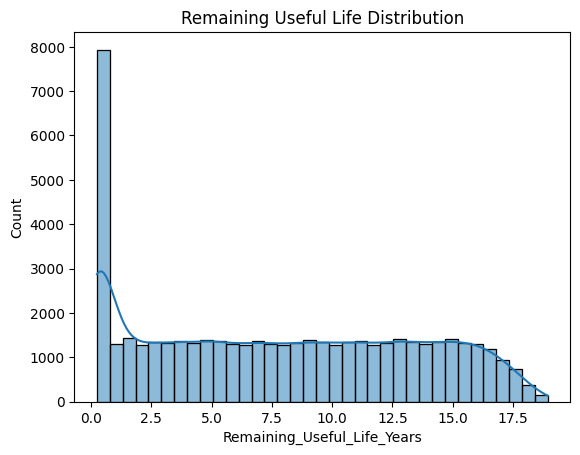

In [ ]:
# Plot the distribution of the target variable 'Remaining_Useful_Life_Years' to understand its spread and shape using histogram

sns.histplot(dataset['Remaining_Useful_Life_Years'], kde=True)
plt.title("Remaining Useful Life Distribution")
plt.show()

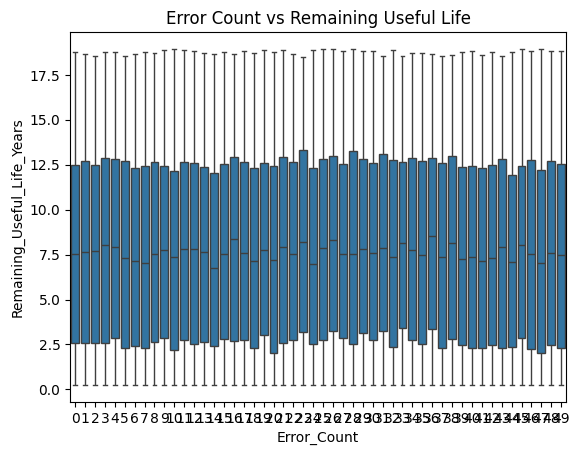

In [ ]:
# Visualize the relationship between 'Error_Count' and 'Remaining_Useful_Life_Years' using a boxplot to see how errors affect lifespan.

sns.boxplot(
    x=dataset['Error_Count'],
    y=dataset['Remaining_Useful_Life_Years']
)
plt.title("Error Count vs Remaining Useful Life")
plt.show()

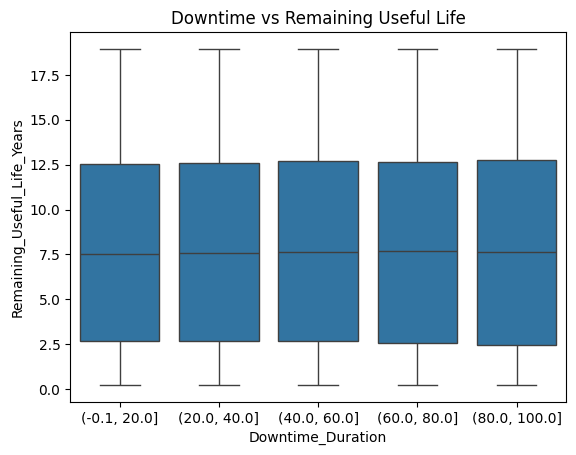

In [ ]:
# Group 'Downtime_Duration' into 5 bins and visualize how different downtime ranges affect 'Remaining_Useful_Life_Years' with a boxplot.

sns.boxplot(
    x=pd.cut(dataset['Downtime_Duration'], bins=5),
    y=dataset['Remaining_Useful_Life_Years']
)
plt.title("Downtime vs Remaining Useful Life")
plt.show()

#  Data Preprocessing and Cleaning

**Objective**


*   The primary objective of data preprocessing is to convert raw medical equipment data into a clean, consistent, and machine-learning-ready format. Proper preprocessing improves data quality, reduces noise, and ensures accurate analysis and model performance.




**Strategy**


The following strategy is adopted for this project:


*  Data Understanding – Inspect dataset structure, size, and data types.
*  Missing Value Handling – Identify and treat missing values using appropriate statistical techniques.
*  Data Type Correction – Convert date and numeric fields into correct formats.

*  Categorical Encoding – Transform categorical variables into numerical form using label encoding.

*   Feature–Target Separation – Separate input variables and target variable for machine learning.
*   Data Storage – Save the cleaned dataset for EDA and model development.


*  Duplicate Removal – Remove redundant records to avoid biased results.


This step-by-step strategy ensures the dataset is accurate, reliable, and suitable for further Exploratory Data Analysis (EDA) and predictive modeling.




# Checking for missing values and duplicated data


In [ ]:
dataset.isnull().sum()
dataset.duplicated().sum()

np.int64(0)

# Droping useless columns & Coverting Data Columns.

In [ ]:


# 1. Drop useless columns
TODAY = pd.to_datetime("today")

# Convert date columns to datetime objects
dataset['Installation_Date'] = pd.to_datetime(dataset['Installation_Date'])
dataset['Last_Maintenance_Date'] = pd.to_datetime(dataset['Last_Maintenance_Date'])

dataset["days_since_installation"] = (TODAY - dataset["Installation_Date"]).dt.days
dataset["days_since_last_maintenance"] = (TODAY - dataset["Last_Maintenance_Date"]).dt.days

dataset.drop([
    'Equipment_ID',
    'Model_Number',
    'Installation_Date',
    'Last_Maintenance_Date'
], axis=1, inplace=True)

In [ ]:
# 2. SEPARATE TARGET & FEATURES
y = dataset['Remaining_Useful_Life_Years']
X = dataset.drop('Remaining_Useful_Life_Years', axis=1)

# Handling Categorical Columns

In [ ]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols

Index(['Equipment_Type', 'Manufacturer', 'Ventilation_Quality',
       'Dust_Exposure_Level', 'Maintenance_Type'],
      dtype='object')

In [ ]:
X = pd.get_dummies(X, drop_first=False)


In [ ]:
X.dtypes

,0
Equipment_Age_Years,int64
Avg_Operating_Hours_Per_Day,float64
Total_Operating_Hours,int64
Power_On_Off_Cycles,int64
Load_Percent,float64
Room_Temperature_C,float64
Humidity_Percent,float64
Maintenance_Count,int64
Parts_Replaced,int64
Avg_Maintenance_Cost,float64


# Outlier Treatment & `Visuals of Outliers`

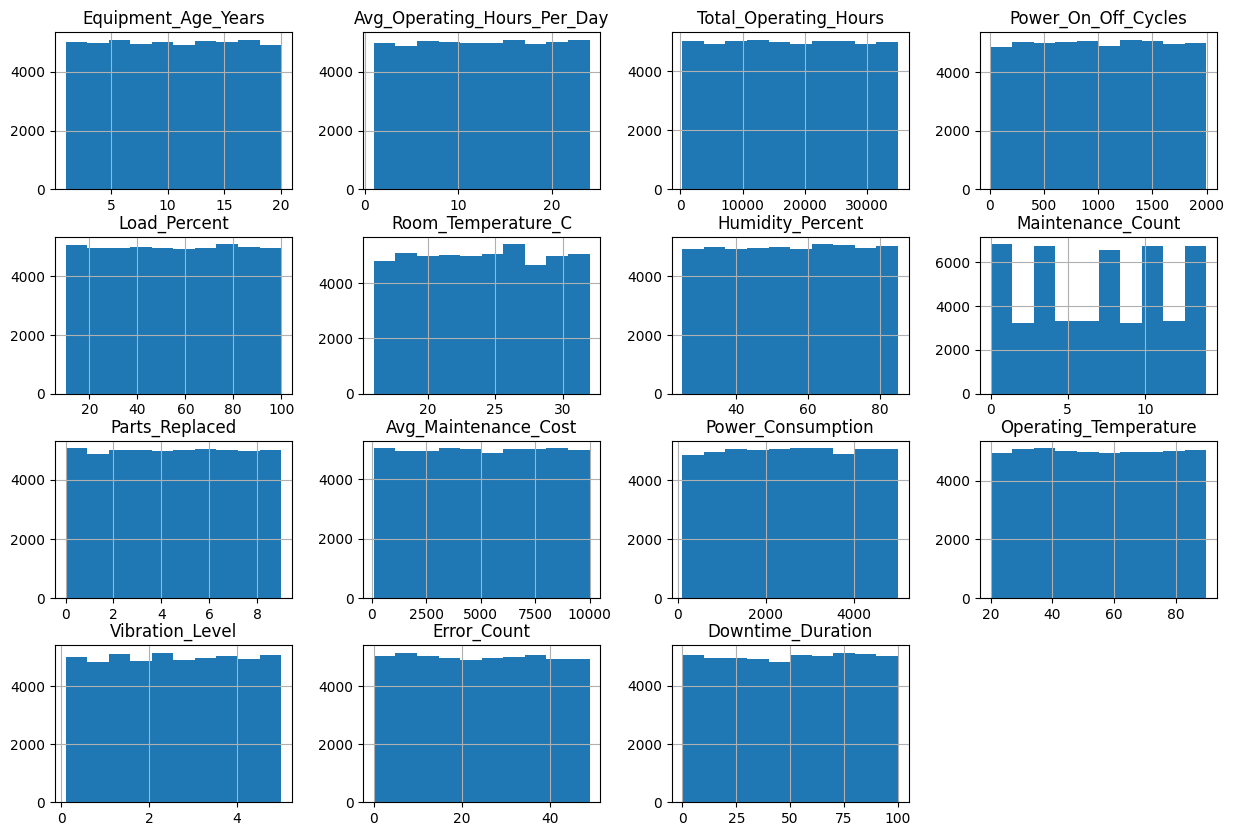

In [ ]:
num_cols = [
    'Equipment_Age_Years', 'Avg_Operating_Hours_Per_Day', 'Total_Operating_Hours',
    'Power_On_Off_Cycles', 'Load_Percent', 'Room_Temperature_C', 'Humidity_Percent',
    'Maintenance_Count', 'Parts_Replaced', 'Avg_Maintenance_Cost', 'Power_Consumption',
    'Operating_Temperature', 'Vibration_Level', 'Error_Count', 'Downtime_Duration'
]

for col in num_cols:
    Q1 = X[col].quantile(0.25)  # First quartile
    Q3 = X[col].quantile(0.75) # Third quartile
    IQR = Q3 - Q1            # Interquartile range
    lower = Q1 - 1.5 * IQR   # Lower outlier threshold
    upper = Q3 + 1.5 * IQR # Upper outlier threshold
    X[col] = np.clip(X[col], lower, upper)

# checking for outliers by ploting histogram:
# X[num_cols].boxplot(rot=45)
# plt.show()
X[num_cols].hist(figsize=(15, 10))
plt.show()


In [ ]:
# Handle skewed features (log1p)
skewed_cols = ['Total_Operating_Hours','Power_On_Off_Cycles','Error_Count','Downtime_Duration']
for col in skewed_cols:
    X[col] = np.log1p(X[col])


# EDA & Data Preprocessing Summary:

1. Dataset contains `50,000` equipment records with no missing values.
2. Date features were converted into meaningful numerical features.
3. Key factors affecting equipment life are `errors`, `downtime`, and `age`.
4. Outliers were handled using `IQR-based` clipping.
5. Categorical variables were encoded using one-hot encoding.
6. Final dataset is clean and ready for model building.

# Model Building
* Model Building involves selecting an appropriate algorithm, training the model on preprocessed data, tuning hyperparameters, and evaluating its performance using standard metrics to ensure accuracy and generalization.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Combine features (X) and target (y) into one dataset

combined_data = pd.concat([X, y], axis=1)
combined_data_cleaned = combined_data.dropna()


# Separate cleaned features and target
X_cleaned = combined_data_cleaned.drop(columns=['Remaining_Useful_Life_Years'])
y_cleaned = combined_data_cleaned['Remaining_Useful_Life_Years']

# FEATURE SCALING
# Standardize features so all variables are on similar scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cleaned)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cleaned, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Model Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
r2_score = lr.score(X_test, y_test)
print("R2 Score (accuracy):", r2_score * 100)

RMSE: 0.49822289552592985
R2 Score (accuracy): 99.19180603709684


# Evaluating `P-value`
*  Runs an OLS regression and prints a detailed summary including `coefficients`, `p-values`, and `model performance metrics`.
where `p-values` < `0.05` indicate statistically significant predictors.

In [ ]:
import statsmodels.api as sm
X_sm = sm.add_constant(X_scaled)
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())

                                 OLS Regression Results                                
Dep. Variable:     Remaining_Useful_Life_Years   R-squared:                       0.992
Model:                                     OLS   Adj. R-squared:                  0.992
Method:                          Least Squares   F-statistic:                 1.889e+05
Date:                         Mon, 12 Jan 2026   Prob (F-statistic):               0.00
Time:                                 07:35:30   Log-Likelihood:                -35791.
No. Observations:                        50000   AIC:                         7.165e+04
Df Residuals:                            49966   BIC:                         7.195e+04
Df Model:                                   33                                         
Covariance Type:                     nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

# Calculates Variance Inflation Factor (VIF) for each feature to detect multicollinearity:
* Here our `VIF` value is approx `1` so it means `no-correlation`


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = ["const"] + list(X.columns)
vif_data["VIF"] = [variance_inflation_factor(X_sm, i) for i in range(X_sm.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                              Feature       VIF
32                    Manufacturer_GE       inf
33             Manufacturer_Medtronic       inf
28          Equipment_Type_Ultrasound       inf
26                 Equipment_Type_ECG       inf
27                 Equipment_Type_MRI       inf
21          Equipment_Type_Ultrasound       inf
22          Equipment_Type_Ventilator       inf
23               Equipment_Type_X-Ray       inf
24  Equipment_Type_Anesthesia Machine       inf
25       Equipment_Type_Defibrillator       inf
18       Equipment_Type_Defibrillator       inf
20                 Equipment_Type_MRI       inf
19                 Equipment_Type_ECG       inf
37        Ventilation_Quality_Average       inf
38           Ventilation_Quality_Good       inf
39           Ventilation_Quality_Poor       inf
40           Dust_Exposure_Level_High       inf
41            Dust_Exposure_Level_Low       inf
34               Manufacturer_Mindray       inf
35               Manufacturer_Philips   

# Perform backward elimination based on p-values

* X pandas DataFrame of features
* y pandas Series of target
* sl significance level

In [ ]:
import statsmodels.api as sm

def backward_elimination(X, y, sl=0.05):

    X = X.copy()
    X_sm = sm.add_constant(X)
    features = list(X.columns)
    while True:
        model = sm.OLS(y, X_sm).fit()
        p_values = model.pvalues.iloc[1:]  # skip constant
        max_p = p_values.max()
        if max_p > sl:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            X_sm = sm.add_constant(X[features])
        else:
            break
    final_model = sm.OLS(y, sm.add_constant(X[features])).fit()
    return features, final_model


# Make X_train a DataFrame with column names
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Ensure y_train is a Series (drop index if needed)
y_train_series = y_train.reset_index(drop=True)

# Run backward elimination
significant_features, final_model = backward_elimination(X_train_df, y_train_series)

print("\nFinal Selected Features:", significant_features)
print(final_model.summary())


Final Selected Features: ['Equipment_Age_Years', 'Avg_Operating_Hours_Per_Day', 'Maintenance_Count']
                                 OLS Regression Results                                
Dep. Variable:     Remaining_Useful_Life_Years   R-squared:                       0.992
Model:                                     OLS   Adj. R-squared:                  0.992
Method:                          Least Squares   F-statistic:                 1.669e+06
Date:                         Mon, 12 Jan 2026   Prob (F-statistic):               0.00
Time:                                 07:35:56   Log-Likelihood:                -28585.
No. Observations:                        40000   AIC:                         5.718e+04
Df Residuals:                            39996   BIC:                         5.721e+04
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                  

# Splitting and Scaling
* Spliting the data into test and train.
*  Applying linear regression model.
*  Scalling has been used.  







In [ ]:
X_train_final = X_train_df[significant_features]
X_test_final = pd.DataFrame(X_test, columns=X.columns)[significant_features]

from sklearn.preprocessing import StandardScaler
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

from sklearn.linear_model import LinearRegression
final_lr_model = LinearRegression()
final_lr_model.fit(X_train_final_scaled, y_train)

LinearRegression()

# Prediction
*  Predicting & Evaluating the model.
*  Test data has been used specifically for this.
*  Only the statistical features have been scaled.


In [ ]:

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_final = final_lr_model.predict(X_test_final_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print(f"Final RMSE: {rmse:.4f}")
print(f"Final R2 Score: {r2:.4f}")

Final RMSE: 0.4981
Final R2 Score: 0.9919


#Actual vs Predicted Remaining Useful Life
* The red line represents perfect predictions (y = x), so points closer to it indicate better predictions.


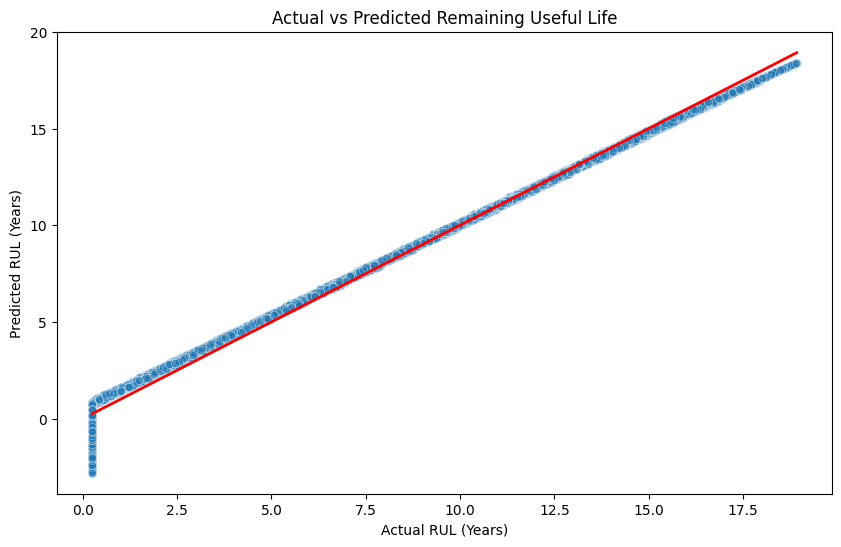

In [ ]:
# Plot a scatterplot comparing actual vs predicted Remaining Useful Life (RUL)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual RUL (Years)")
plt.ylabel("Predicted RUL (Years)")
plt.title("Actual vs Predicted Remaining Useful Life")
plt.show()

#Correlation Matrix (Analysis)


Remaining_Useful_Life_Years    1.000000
Humidity_Percent               0.007726
Parts_Replaced                 0.006932
Load_Percent                   0.003790
days_since_last_maintenance    0.002270
Avg_Maintenance_Cost           0.000835
Error_Count                    0.000238
Total_Operating_Hours         -0.000065
Downtime_Duration             -0.000528
Vibration_Level               -0.000735
Power_On_Off_Cycles           -0.001472
days_since_installation       -0.001492
Operating_Temperature         -0.002058
Power_Consumption             -0.004677
Room_Temperature_C            -0.009688
Avg_Operating_Hours_Per_Day   -0.051000
Maintenance_Count             -0.125020
Equipment_Age_Years           -0.987081
Name: Remaining_Useful_Life_Years, dtype: float64


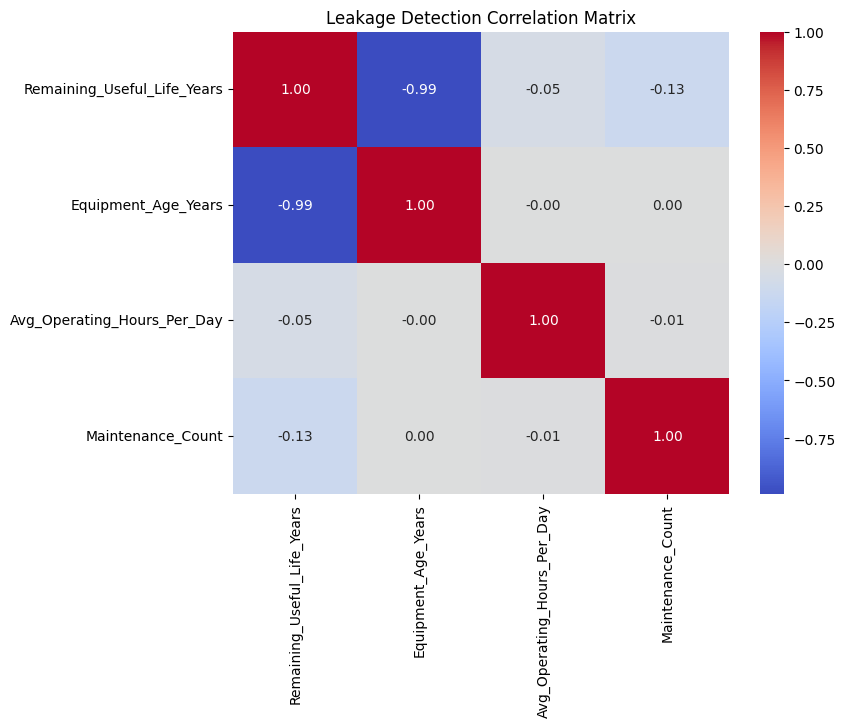

In [ ]:
# Calculate correlation of all numeric features with the target 'Remaining_Useful_Life_Years' and print it
corr_df = dataset.select_dtypes(include=[np.number])
target_corr = corr_df.corr()["Remaining_Useful_Life_Years"].sort_values(ascending=False)
print(target_corr)

# Plot a heatmap of selected features to visualize their correlation with each other and the target
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df[[
        'Remaining_Useful_Life_Years',
        'Equipment_Age_Years',
        'Avg_Operating_Hours_Per_Day',
        'Maintenance_Count'
    ]].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Leakage Detection Correlation Matrix")
plt.show()

##Removing the leakage


In [ ]:
# overcome overfitting (Remove leakage-related features that may cause overfitting)
leakage_features = [
    'Total_Operating_Hours',
    'days_since_installation'
]

X_clean = X.drop(columns=leakage_features)

In [ ]:
# Select only the important features for the final model to focus on the most relevant predictors
important_features = [
    'Equipment_Age_Years',
    'Error_Count',
    'Downtime_Duration',
    'Maintenance_Count'
] + [col for col in X_clean.columns if col.startswith("Equipment_Type_")]

X_final = X_clean[important_features]

#Training and Testing
Calculating the values of RMSE and R2_value

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred_final)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 0.5749056237478758
R2: 0.9919235273987206


#Residual Analysis

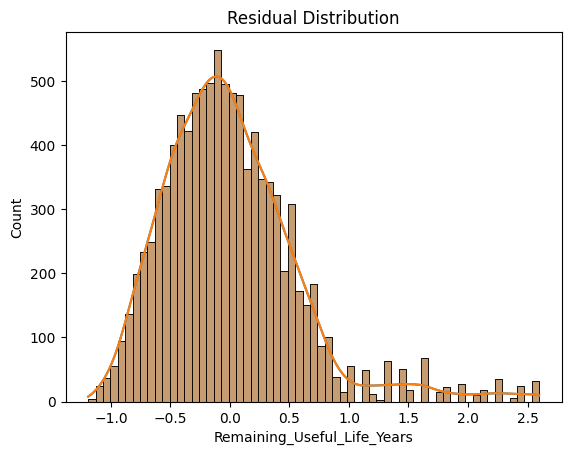

In [ ]:
# Calculate residuals (differences between actual and predicted values)

residuals = y_test - y_pred

# Plot histogram with KDE to check if residuals are normally distributed (important for regression assumptions)
sns.histplot(residuals, kde=True)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [ ]:
# Create a DataFrame showing feature names and their corresponding linear regression coefficients,
# then sort features by the absolute value of their coefficients to highlight the most impactful predictors.
importance = pd.DataFrame({
    "Feature": X_final.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

importance

,Feature,Coefficient
0,Equipment_Age_Years,-5.482271
3,Maintenance_Count,-0.677613
1,Error_Count,0.003686
2,Downtime_Duration,0.003105
6,Equipment_Type_ECG,0.001045
20,Equipment_Type_ECG,0.001045
19,Equipment_Type_ECG,0.001045
7,Equipment_Type_ECG,0.001045
8,Equipment_Type_MRI,-0.000983
9,Equipment_Type_MRI,-0.000983


#Risk Evaluation

In [ ]:
risk_df = pd.DataFrame({
    "Actual_RUL": y_test,
    "Predicted_RUL": y_pred
})
equipment_type_cols = [col for col in X_test.columns if col.startswith("Equipment_Type_")]

if equipment_type_cols:
    risk_df["Equipment_Type"] = X_test[equipment_type_cols].idxmax(axis=1)
    risk_df["Equipment_Type"] = risk_df["Equipment_Type"].str.replace("Equipment_Type_", "")

risk_df["Risk_Level"] = pd.cut(
    risk_df["Predicted_RUL"],
    bins=[-np.inf, 2, 5, np.inf],
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

risk_df.head(9)

,Actual_RUL,Predicted_RUL,Equipment_Type,Risk_Level
33553,2.74,2.883465,MRI,Medium Risk
9427,0.25,-0.598009,Defibrillator,High Risk
199,18.05,17.762810,Ultrasound,Low Risk
12447,8.52,8.425911,Ventilator,Low Risk
39489,14.74,14.947871,Defibrillator,Low Risk
42724,17.86,17.929759,Ventilator,Low Risk
10822,3.71,4.009267,ECG,Medium Risk
49498,13.21,13.368730,ECG,Low Risk
4144,0.50,0.506159,Ultrasound,High Risk


#Final Statistical Analysis

In [ ]:
X_final_df = pd.DataFrame(X_final, columns=X_final.columns).astype(float)
import statsmodels.api as sm
X_final_sm = sm.add_constant(X_final_df, has_constant='add')  # ensures constant is not duplicated

# 3. Ensure y is aligned and numeric
y_clean_numeric = y.reset_index(drop=True).astype(float)

# 4. Fit OLS model
ols_final = sm.OLS(y_clean_numeric, X_final_sm).fit()

# 5. Print summary
print(ols_final.summary())


                                 OLS Regression Results                                
Dep. Variable:     Remaining_Useful_Life_Years   R-squared:                       0.989
Model:                                     OLS   Adj. R-squared:                  0.989
Method:                          Least Squares   F-statistic:                 4.615e+05
Date:                         Mon, 12 Jan 2026   Prob (F-statistic):               0.00
Time:                                 07:37:17   Log-Likelihood:                -43252.
No. Observations:                        50000   AIC:                         8.653e+04
Df Residuals:                            49989   BIC:                         8.662e+04
Df Model:                                   10                                         
Covariance Type:                     nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------

# Evaluating Cross Validation

In [ ]:
# A. Cross-validation & robustness check
from sklearn.model_selection import cross_val_score, KFold

scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)  # scale all rows
lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(lr, X_final_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')
cv_r2 = cross_val_score(lr, X_final_scaled, y, cv=kf, scoring='r2')

#  Results
print(f"Cross-validated RMSE: {cv_rmse.mean():.4f}")
print(f"Cross-validated R2: {cv_r2.mean():.4f}")

Cross-validated RMSE: 0.5748
Cross-validated R2: 0.9893


#Visualization of Residual Distribution

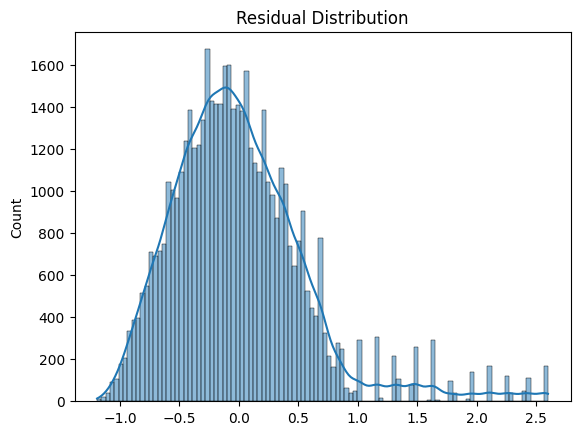

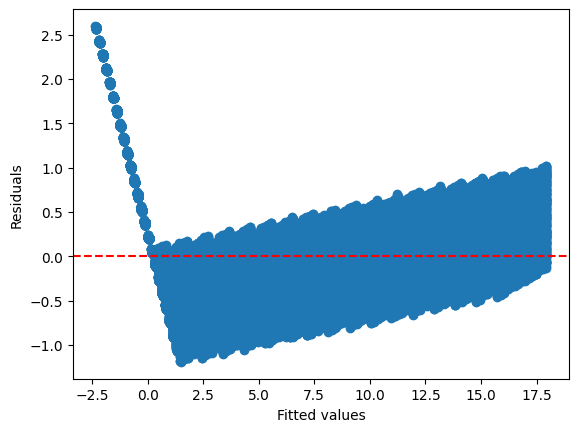

Breusch-Pagan p-value: 0.0
Durbin-Watson statistic: 2.0023370181404667


In [ ]:
# B.Residual diagnostics
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# Fit OLS on final features
X_sm = sm.add_constant(X_final_df)
ols = sm.OLS(y, X_sm).fit()

# 1. Residuals
residuals = ols.resid

# 2. Normality
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# 3. Homoscedasticity
plt.scatter(ols.fittedvalues, residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Breusch-Pagan test
bp_test = het_breuschpagan(residuals, X_sm)
print("Breusch-Pagan p-value:", bp_test[1])  # p>0.05 → homoscedastic

# 4. Autocorrelation
dw = durbin_watson(residuals)
print("Durbin-Watson statistic:", dw)  # close to 2 → no autocorrelation


#Comparison with other ML models

In [ ]:
# C. Trying alternative models for comparison
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

print("Model Performance Comparison:\n")
for name, model in models.items():
    # Scale only for linear models
    if name in ["LinearRegression", "Ridge", "Lasso", "ElasticNet"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{name:<20} RMSE: {rmse:.4f}, R2: {r2:.4f}")


Model Performance Comparison:

LinearRegression     RMSE: 0.5749, R2: 0.9892
Ridge                RMSE: 0.5749, R2: 0.9892
Lasso                RMSE: 0.5752, R2: 0.9892
ElasticNet           RMSE: 0.5762, R2: 0.9892
RandomForest         RMSE: 0.3343, R2: 0.9964
GradientBoosting     RMSE: 0.3130, R2: 0.9968


#Training Gradient Boosting Model


In [ ]:
# Train a Gradient Boosting model, then compute and display feature importances
# using permutation importance on the test data to understand which features impact predictions most.

from sklearn.inspection import permutation_importance
import pandas as pd

# use your best model (example: Gradient Boosting)
model = GradientBoostingRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X_final.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
0,Equipment_Age_Years,1.943509e+00
3,Maintenance_Count,3.365609e-02
2,Downtime_Duration,2.800926e-06
1,Error_Count,9.766012e-07
16,Equipment_Type_Anesthesia Machine,2.743467e-07
26,Equipment_Type_Ventilator,1.954737e-07
25,Equipment_Type_Ventilator,1.954737e-07
13,Equipment_Type_Ventilator,1.954737e-07
12,Equipment_Type_Ventilator,1.954737e-07
15,Equipment_Type_X-Ray,5.674452e-08


# Out-of-sample validation + Final model : Gradient Boosting

In [ ]:
# Model Used: Gradient Boosting Regressor
# Reason: Handles non-linearity and feature interactions

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Add Equipment_Type dummies BEFORE splitting
equipment_dummies = pd.get_dummies(dataset['Equipment_Type'], prefix='Equipment_Type', drop_first=False)
dataset = pd.concat([dataset, equipment_dummies], axis=1)

# 2. Sort by installation time
data_sorted = dataset.sort_values("days_since_installation")

split = int(0.8 * len(data_sorted))
train = data_sorted.iloc[:split]
test = data_sorted.iloc[split:]

# 3. Prepare features (important + equipment type dummies)
feature_cols = important_features + [col for col in dataset.columns if col.startswith("Equipment_Type_")]

X_train = train[feature_cols]
y_train = train["Remaining_Useful_Life_Years"]

X_test = test[feature_cols]
y_test = test["Remaining_Useful_Life_Years"]

# 4. Gradient Boosting Regressor (no scaling needed)
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

# 5. Predictions & evaluation
y_pred = gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Out-of-sample RMSE:", rmse)
print("Out-of-sample R2:", r2)


Out-of-sample RMSE: 0.3110500450535507
Out-of-sample R2: 0.996883471921641


# Adjusted R2_Value

In [ ]:
# Number of observations and predictors
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Out-of-sample Adjusted R2:", adjusted_r2)


Out-of-sample Adjusted R2: 0.9968360072844439
